In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Eda

## Finding some good stuff

In [2]:
df = pd.read_csv('ai_worker_burnout_attrition_2026.csv')
df

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,EMP1496,Frontend Engineer,2,Master,Brazil,Fintech,Enterprise (5000+),Hybrid,36,47,...,7,6.9,69,Integrating,2.6,74,63,3.1,High,Medium
1496,EMP1497,Prompt Engineer,1,PhD,UK,E-commerce,Small (50-200),Hybrid,22,199,...,1,1.2,7,Integrating,6.9,39,25,3.5,Low,Low
1497,EMP1498,Backend Engineer,8,Bachelor,Canada,Cybersecurity,Mid (200-1000),Hybrid,48,120,...,3,6.8,73,Optimizing,4.0,44,65,2.9,High,High
1498,EMP1499,AI Ethics Officer,13,Self-taught,Netherlands,Media,Startup (<50),Fully Remote,41,208,...,6,3.2,68,Optimizing,4.1,77,53,2.8,Low,Medium


In [3]:
df['company_size'].value_counts()

company_size
Mid (200-1000)        317
Enterprise (5000+)    312
Startup (<50)         311
Large (1000-5000)     286
Small (50-200)        274
Name: count, dtype: int64

In [4]:
df['job_role'].unique()

<StringArray>
[     'Data Analyst',   'DevOps Engineer',   'Prompt Engineer',
  'Backend Engineer',     'AI Researcher', 'AI Ethics Officer',
    'Data Scientist',   'Product Manager',       'ML Engineer',
   'Cloud Architect', 'Software Engineer', 'Frontend Engineer']
Length: 12, dtype: str

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   employee_id                     1500 non-null   str    
 1   job_role                        1500 non-null   str    
 2   years_experience                1500 non-null   int64  
 3   education_level                 1500 non-null   str    
 4   country                         1500 non-null   str    
 5   industry                        1500 non-null   str    
 6   company_size                    1500 non-null   str    
 7   remote_work_type                1500 non-null   str    
 8   team_size                       1500 non-null   int64  
 9   salary_usd_k                    1500 non-null   int64  
 10  primary_ai_tool                 1500 non-null   str    
 11  ai_tools_used_per_day           1500 non-null   int64  
 12  hours_with_ai_assistance_daily  1500 non-null

In [6]:
df.isna().sum()

employee_id                       0
job_role                          0
years_experience                  0
education_level                   0
country                           0
industry                          0
company_size                      0
remote_work_type                  0
team_size                         0
salary_usd_k                      0
primary_ai_tool                   0
ai_tools_used_per_day             0
hours_with_ai_assistance_daily    0
ai_replaces_my_tasks_pct          0
ai_adoption_stage                 0
weekly_ai_upskilling_hrs          0
productivity_score                0
burnout_score                     0
job_satisfaction_1_5              0
fear_of_ai_replacement            0
attrition_risk                    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,years_experience,team_size,salary_usd_k,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5
count,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,9.947333,24.812667,140.734000,4.05600,4.233733,41.248667,4.985533,57.543333,50.057333,3.334733
std,5.460932,13.682582,59.717429,1.97403,2.148387,21.658214,2.913933,10.726952,11.437771,0.636692
min,1.000000,2.000000,40.000000,1.00000,0.500000,5.000000,0.000000,25.000000,16.000000,1.300000
25%,5.000000,13.000000,91.000000,2.00000,2.400000,22.750000,2.400000,50.000000,42.000000,2.900000
50%,10.000000,25.000000,139.000000,4.00000,4.200000,40.000000,5.000000,57.000000,50.000000,3.300000
75%,15.000000,36.000000,190.000000,6.00000,6.100000,60.000000,7.500000,65.000000,58.000000,3.800000
max,19.000000,49.000000,249.000000,7.00000,8.000000,79.000000,10.000000,95.000000,86.000000,5.000000


In [9]:
df['job_satisfaction_1_5'].describe()

count    1500.000000
mean        3.334733
std         0.636692
min         1.300000
25%         2.900000
50%         3.300000
75%         3.800000
max         5.000000
Name: job_satisfaction_1_5, dtype: float64

In [10]:
interval = (df['job_satisfaction_1_5'].max() - df['job_satisfaction_1_5'].min())/3
interval

np.float64(1.2333333333333334)

In [11]:
low_max_inter = df['job_satisfaction_1_5'].min() +  interval
med_max_inter = low_max_inter + interval
high_max_inter = med_max_inter + interval

low = [0, low_max_inter]
medium = [low_max_inter, med_max_inter]
high = [med_max_inter, high_max_inter]

print('low: ',low)
print('medium: ',medium)
print('high: ',high)

low:  [0, np.float64(2.533333333333333)]
medium:  [np.float64(2.533333333333333), np.float64(3.7666666666666666)]
high:  [np.float64(3.7666666666666666), np.float64(5.0)]


In [12]:
bins = [0, low_max_inter, med_max_inter, high_max_inter]
kelas = ['Low', 'Medium/Netral', 'High']

In [13]:
df['job_satisfaction_category'] = pd.cut(df['job_satisfaction_1_5'], bins=bins, labels=kelas)

In [14]:
df[['job_satisfaction_1_5','job_satisfaction_category']]

,job_satisfaction_1_5,job_satisfaction_category
0,3.0,Medium/Netral
1,3.6,Medium/Netral
2,4.6,High
3,3.0,Medium/Netral
4,3.6,Medium/Netral
...,...,...
1495,3.1,Medium/Netral
1496,3.5,Medium/Netral
1497,2.9,Medium/Netral
1498,2.8,Medium/Netral


In [15]:
df['job_satisfaction_category'].value_counts()

job_satisfaction_category
Medium/Netral    934
High             401
Low              165
Name: count, dtype: int64

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   employee_id                     1500 non-null   str     
 1   job_role                        1500 non-null   str     
 2   years_experience                1500 non-null   int64   
 3   education_level                 1500 non-null   str     
 4   country                         1500 non-null   str     
 5   industry                        1500 non-null   str     
 6   company_size                    1500 non-null   str     
 7   remote_work_type                1500 non-null   str     
 8   team_size                       1500 non-null   int64   
 9   salary_usd_k                    1500 non-null   int64   
 10  primary_ai_tool                 1500 non-null   str     
 11  ai_tools_used_per_day           1500 non-null   int64   
 12  hours_with_ai_assistance_daily 

In [17]:
df.value_counts(['ai_adoption_stage','job_satisfaction_category']).unstack()

job_satisfaction_category,Low,Medium/Netral,High
ai_adoption_stage,,,
Experimenting,41,221,96
Optimizing,43,251,106
Integrating,52,309,131
AI-First,29,153,68


In [18]:
table = df.value_counts(['ai_adoption_stage','job_satisfaction_category']).unstack()
percent_table = (table.div(table.sum(axis=1), axis=0) * 100).round(2)
percent_table

job_satisfaction_category,Low,Medium/Netral,High
ai_adoption_stage,,,
Experimenting,11.45,61.73,26.82
Optimizing,10.75,62.75,26.50
Integrating,10.57,62.80,26.63
AI-First,11.60,61.20,27.20


In [19]:
df.groupby('job_satisfaction_category')[[
    'salary_usd_k',
    'years_experience',
    'ai_tools_used_per_day',
    'hours_with_ai_assistance_daily',
    'ai_replaces_my_tasks_pct',
    'weekly_ai_upskilling_hrs',
    'productivity_score',
    'burnout_score'
]].mean()

,salary_usd_k,years_experience,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,weekly_ai_upskilling_hrs,productivity_score,burnout_score
job_satisfaction_category,,,,,,,,
Low,144.793939,10.230303,3.872727,5.096970,57.224242,5.069697,57.430303,62.727273
Medium/Netral,140.148822,9.794433,4.049251,4.359743,42.483940,5.039615,57.573876,51.423983
High,140.426434,10.187032,4.147132,3.585037,31.798005,4.824938,57.518703,41.660848


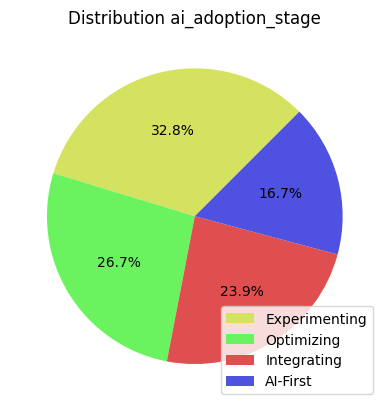

In [20]:
custom_colors = ["#d5e260", "#6bf35f", "#e04f4f", "#4f51e0"]

label = df["ai_adoption_stage"].unique()
size = df["ai_adoption_stage"].value_counts()

plt.pie(size, autopct="%1.1f%%", startangle=45, colors=custom_colors)
plt.title("Distribution ai_adoption_stage")
plt.legend(label)

/tmp/ipykernel_10296/3962348766.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='job_satisfaction_category', y='hours_with_ai_assistance_daily', data=df, palette=custom_colors, errorbar=None)


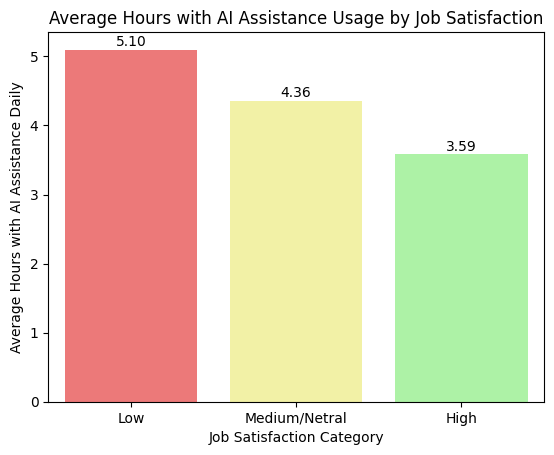

In [21]:
custom_colors = ["#ff6666", "#fffd99", "#a2ff99"]
ax = sns.barplot(x='job_satisfaction_category', y='hours_with_ai_assistance_daily', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("Average Hours with AI Assistance Daily")
plt.xlabel("Job Satisfaction Category")
plt.title("Average Hours with AI Assistance Usage by Job Satisfaction")
plt.show()


In [22]:
df['fear_of_ai_replacement'].unique()

<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

/tmp/ipykernel_10296/3736758761.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


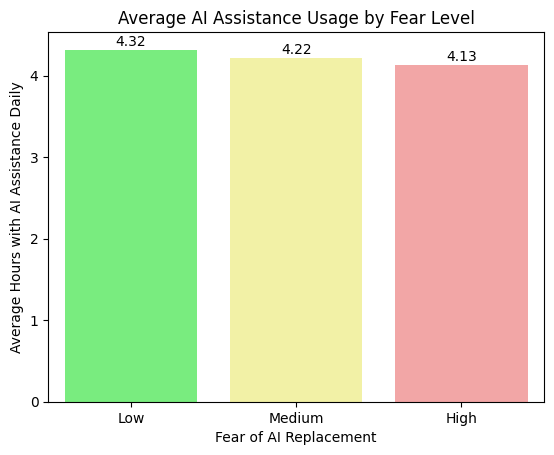

In [23]:
custom_colors = ["#66ff6e", "#fffd99", "#ff9999"]
ax = sns.barplot(
    x='fear_of_ai_replacement',
    y='hours_with_ai_assistance_daily',
    data=df,
    palette=custom_colors,
    errorbar=None

)

# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("Average Hours with AI Assistance Daily")
plt.xlabel("Fear of AI Replacement")
plt.title("Average AI Assistance Usage by Fear Level")
plt.show()

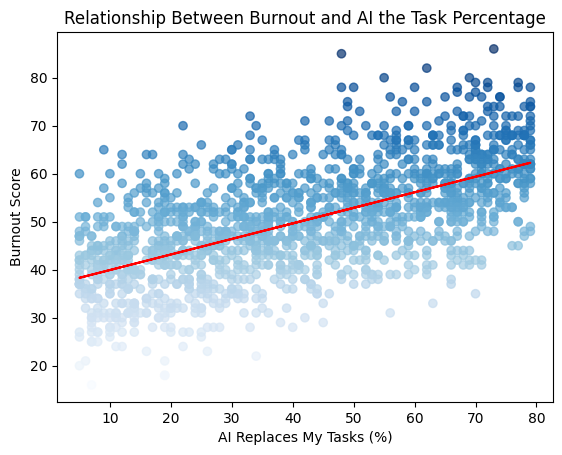

In [24]:
import numpy as np
y = df['burnout_score']
x = df['ai_replaces_my_tasks_pct']

plt.scatter(x, y, c=y, cmap='Blues', alpha=0.7)

# membuat garis regresi linear
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red')

# label sumbu
plt.ylabel("Burnout Score")
plt.xlabel("AI Replaces My Tasks (%)")

# judul (opsional)
plt.title("Relationship Between Burnout and AI the Task Percentage")

plt.show()

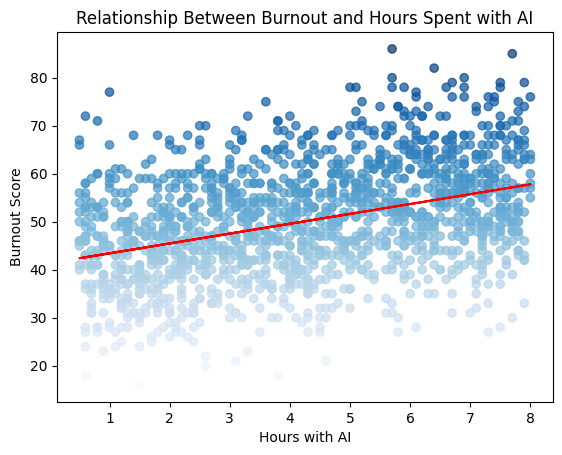

In [25]:
y = df['burnout_score']
x = df['hours_with_ai_assistance_daily']

plt.scatter(x, y, c=y, cmap='Blues', alpha=0.7)

# membuat garis regresi linear
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red')

# label sumbu
plt.ylabel("Burnout Score")
plt.xlabel("Hours with AI")

# judul (opsional)
plt.title("Relationship Between Burnout and Hours Spent with AI")

plt.show()

In [26]:
df['education_level'].unique()

<StringArray>
['PhD', 'Self-taught', 'Master', 'Bachelor', 'Bootcamp']
Length: 5, dtype: str

/tmp/ipykernel_10296/311812148.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


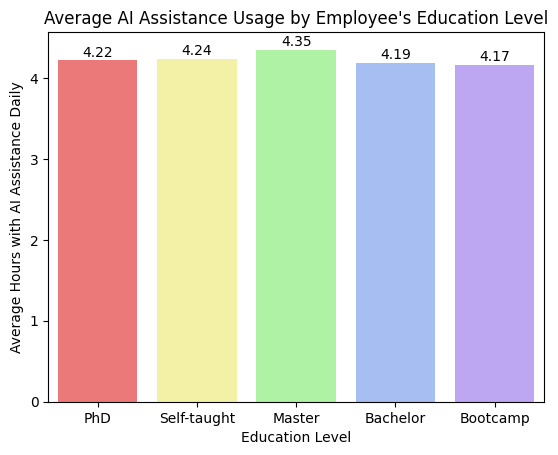

In [27]:
custom_colors = ["#ff6666", "#fffd99", "#a5ff99", "#99b9ff", "#b899ff"]
ax = sns.barplot(
    x='education_level',
    y='hours_with_ai_assistance_daily',
    data=df,
    palette=custom_colors,
    errorbar=None

)

# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("Average Hours with AI Assistance Daily")
plt.xlabel("Education Level")
plt.title("Average AI Assistance Usage by Employee's Education Level")
plt.show()

/tmp/ipykernel_10296/389923524.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


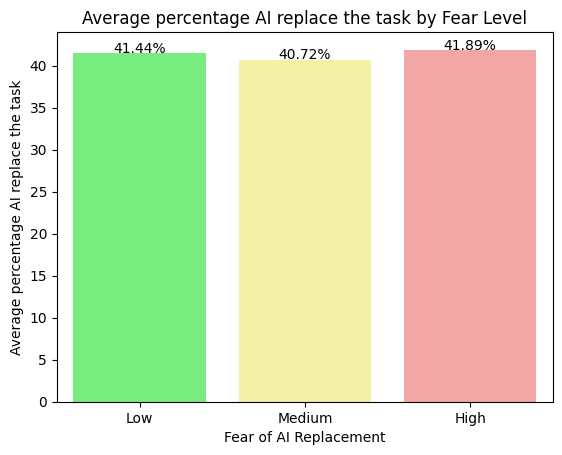

In [28]:
custom_colors = ["#66ff6e", "#fffd99", "#ff9999"]
ax = sns.barplot(
    x='fear_of_ai_replacement',
    y='ai_replaces_my_tasks_pct',
    data=df,
    palette=custom_colors,
    errorbar=None

)

# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}%",
        ha='center'
    )

plt.ylabel("Average percentage AI replace the task")
plt.xlabel("Fear of AI Replacement")
plt.title("Average percentage AI replace the task by Fear Level")
plt.show()

/tmp/ipykernel_10296/3727660582.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


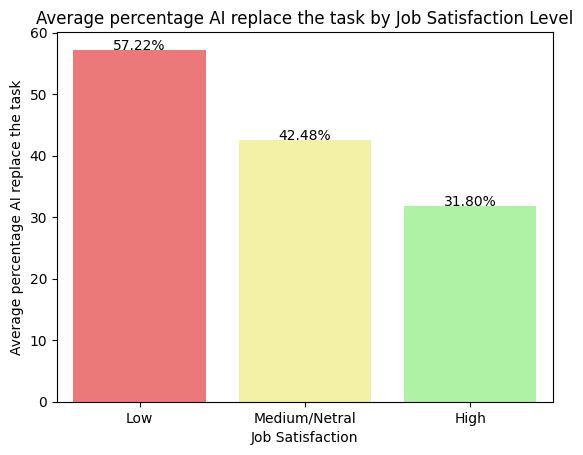

In [29]:
custom_colors = ["#ff6666", "#fffd99", "#a5ff99"]
ax = sns.barplot(
    x='job_satisfaction_category',
    y='ai_replaces_my_tasks_pct',
    data=df,
    palette=custom_colors,
    errorbar=None

)

# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}%",
        ha='center'
    )

plt.ylabel("Average percentage AI replace the task")
plt.xlabel("Job Satisfaction")
plt.title("Average percentage AI replace the task by Job Satisfaction Level")
plt.show()

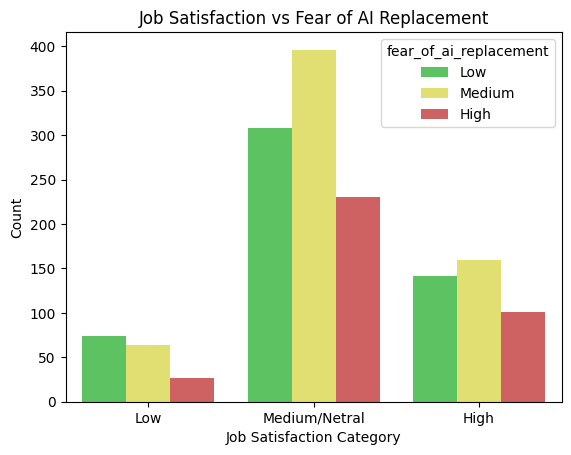

In [30]:
custom_colors = ["#4cd352", "#f3f15f", "#e04f4f"]

sns.countplot(
    x='job_satisfaction_category',
    hue='fear_of_ai_replacement',
    data=df,
    palette=custom_colors
)

plt.title("Job Satisfaction vs Fear of AI Replacement")
plt.xlabel("Job Satisfaction Category")
plt.ylabel("Count")
plt.show()

In [31]:
df['attrition_risk'].unique()

<StringArray>
['Medium', 'Low', 'High']
Length: 3, dtype: str

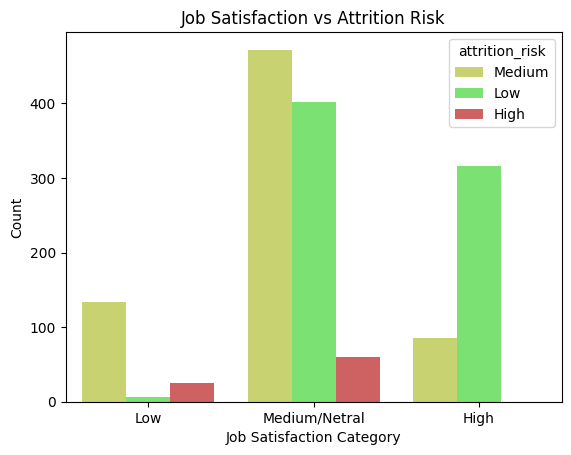

In [32]:
custom_colors = ["#d5e260", "#6bf35f", "#e04f4f"]

sns.countplot(
    x='job_satisfaction_category',
    hue='attrition_risk',
    data=df,
    palette=custom_colors
)

plt.title("Job Satisfaction vs Attrition Risk")
plt.xlabel("Job Satisfaction Category")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_10296/2857771013.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='job_satisfaction_category', y='burnout_score', data=df, palette=custom_colors, errorbar=None)


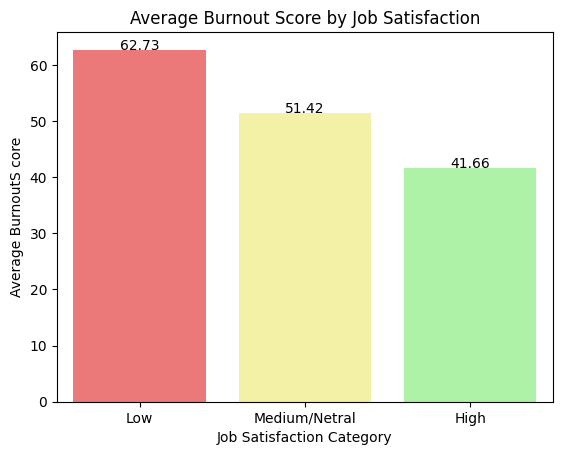

In [33]:
custom_colors = ["#ff6666", "#fffd99", "#a2ff99"]
ax = sns.barplot(x='job_satisfaction_category', y='burnout_score', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("Average BurnoutS core")
plt.xlabel("Job Satisfaction Category")
plt.title("Average Burnout Score by Job Satisfaction")
plt.show()


/tmp/ipykernel_10296/3826507753.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='attrition_risk', y='burnout_score', data=df, palette=custom_colors, errorbar=None)


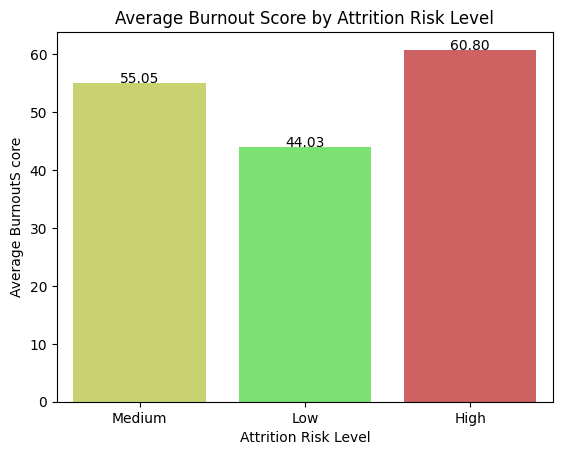

In [34]:
custom_colors = ["#d5e260", "#6bf35f", "#e04f4f"]
ax = sns.barplot(x='attrition_risk', y='burnout_score', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("Average BurnoutS core")
plt.xlabel("Attrition Risk Level")
plt.title("Average Burnout Score by Attrition Risk Level")
plt.show()


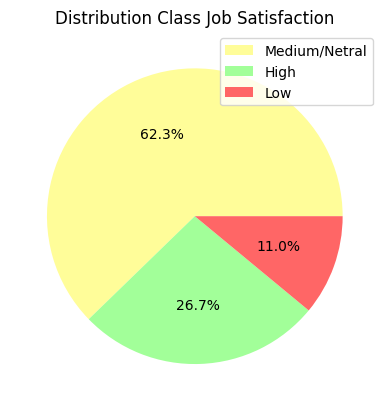

In [35]:
custom_colors = ["#fffd99","#a2ff99", "#ff6666"]

label = df["job_satisfaction_category"].unique()
size = df["job_satisfaction_category"].value_counts()

plt.pie(size, autopct="%1.1f%%", colors=custom_colors)
plt.title("Distribution Class Job Satisfaction")
plt.legend(label)

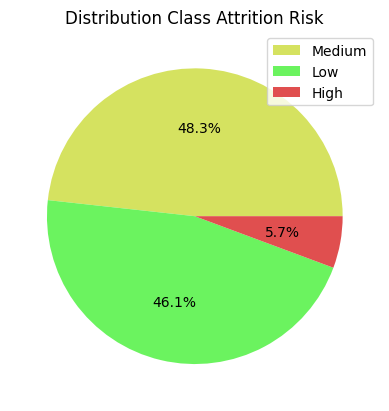

In [36]:
custom_colors = ["#d5e260", "#6bf35f", "#e04f4f"]

label = df["attrition_risk"].unique()
size = df["attrition_risk"].value_counts()

plt.pie(size, autopct="%1.1f%%", colors=custom_colors)
plt.title("Distribution Class Attrition Risk")
plt.legend(label)

/tmp/ipykernel_10296/2457328889.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='job_satisfaction_category', y='salary_usd_k', data=df, palette=custom_colors, errorbar=None)


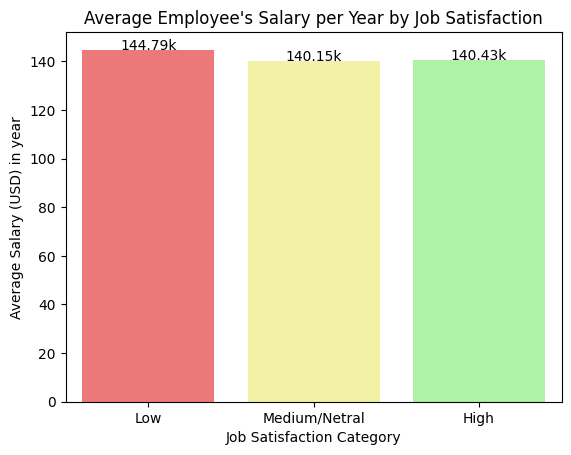

In [37]:

custom_colors = ["#ff6666", "#fffd99", "#a2ff99"]
ax = sns.barplot(x='job_satisfaction_category', y='salary_usd_k', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}k",
        ha='center'
    )

plt.ylabel("Average Salary (USD) in year")
plt.xlabel("Job Satisfaction Category")
plt.title("Average Employee's Salary per Year by Job Satisfaction")
plt.show()


/tmp/ipykernel_10296/553149449.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='attrition_risk', y='salary_usd_k', data=df, palette=custom_colors, errorbar=None)


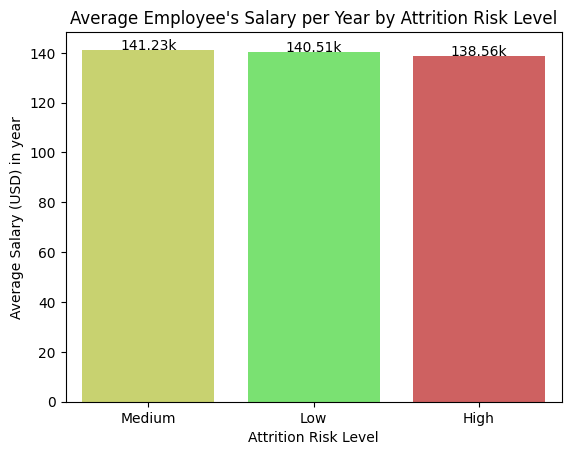

In [38]:

custom_colors = ["#d5e260", "#6bf35f", "#e04f4f"]
ax = sns.barplot(x='attrition_risk', y='salary_usd_k', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}k",
        ha='center'
    )

plt.ylabel("Average Salary (USD) in year")
plt.xlabel("Attrition Risk Level")
plt.title("Average Employee's Salary per Year by Attrition Risk Level")
plt.show()


/tmp/ipykernel_10296/1387032933.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='attrition_risk', y='years_experience', data=df, palette=custom_colors, errorbar=None)


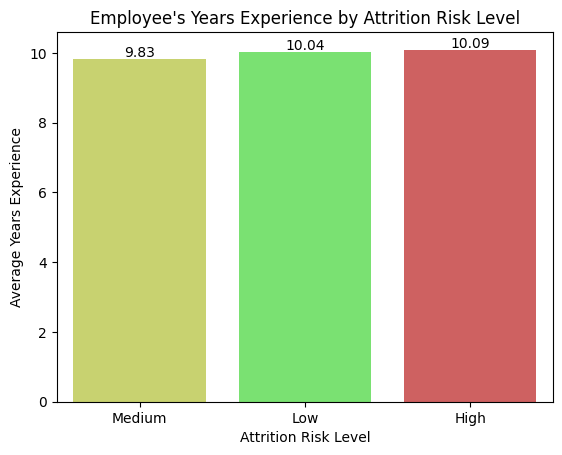

In [39]:
custom_colors = ["#d5e260", "#6bf35f", "#e04f4f"]
ax = sns.barplot(x='attrition_risk', y='years_experience', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("Average Years Experience")
plt.xlabel("Attrition Risk Level")
plt.title("Employee's Years Experience by Attrition Risk Level")
plt.show()


/tmp/ipykernel_10296/3919846008.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='job_satisfaction_category', y='years_experience', data=df, palette=custom_colors, errorbar=None)


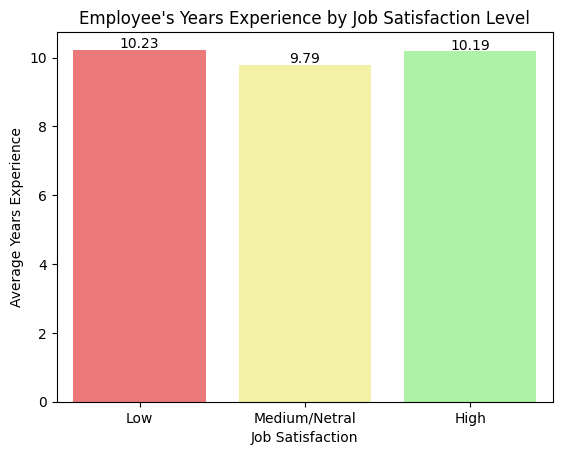

In [40]:
custom_colors = ["#ff6666", "#fffd99", "#a2ff99"]
ax = sns.barplot(x='job_satisfaction_category', y='years_experience', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("Average Years Experience")
plt.xlabel("Job Satisfaction")
plt.title("Employee's Years Experience by Job Satisfaction Level")
plt.show()


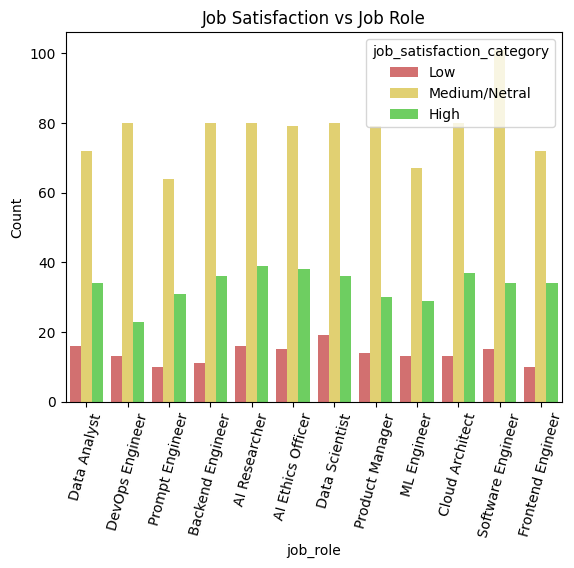

In [41]:
custom_colors = ["#e26060", "#f3dd5f", "#60e04f"]

sns.countplot(
    x='job_role',
    hue='job_satisfaction_category',
    data=df,
    palette=custom_colors
)

plt.title("Job Satisfaction vs Job Role")
plt.xticks(rotation=75)
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_10296/1945066618.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='ai_replaces_my_tasks_pct', y='job_role', data=df, palette="rocket", errorbar=None)


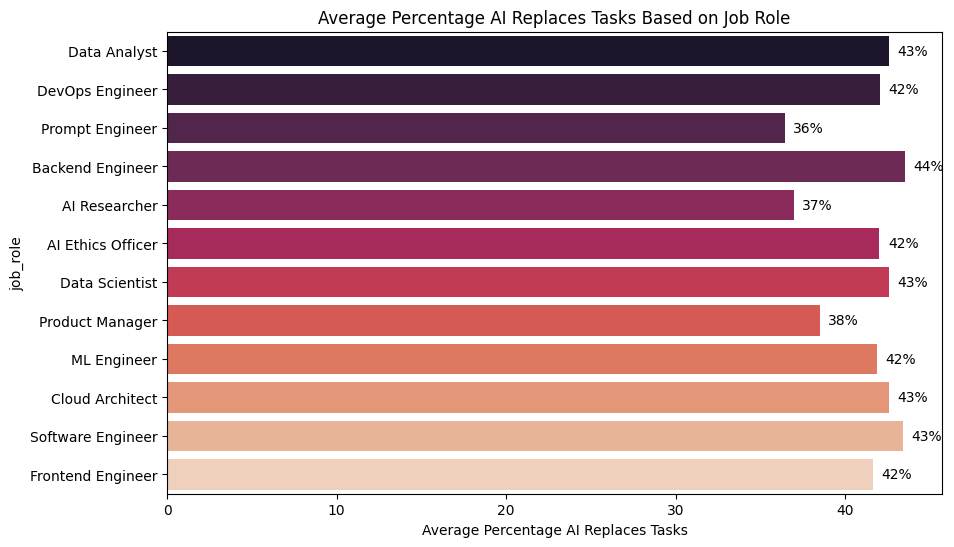

In [42]:
plt.figure(figsize=(10,6))
ax = sns.barplot(x='ai_replaces_my_tasks_pct', y='job_role', data=df, palette="rocket", errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    # Untuk bar horizontal:
    # width = nilai (sumbu x)
    # y = posisi bar (sumbu y)
    width = p.get_width() 
    
    ax.text(
        width + 0.5,                # Posisi X: sedikit di kanan ujung bar
        p.get_y() + p.get_height()/2, # Posisi Y: tepat di tengah ketebalan bar
        f'{width:.0f}%',          # Format teks
        va='center'               # Alignment vertikal agar presisi di tengah
    )

plt.xlabel("Average Percentage AI Replaces Tasks")

plt.title("Average Percentage AI Replaces Tasks Based on Job Role")
plt.show()


/tmp/ipykernel_10296/2705096141.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='job_satisfaction_category', y='team_size', data=df, palette=custom_colors, errorbar=None)


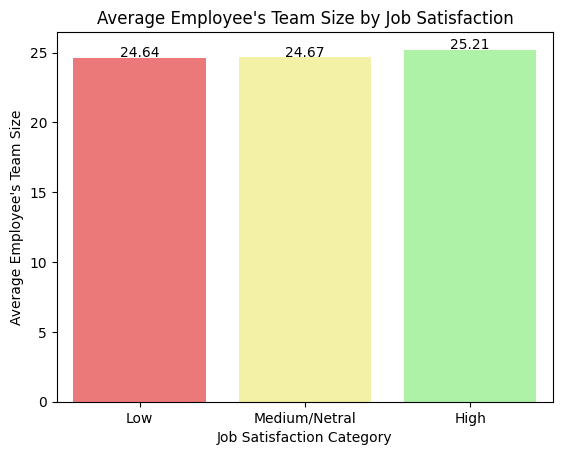

In [43]:
custom_colors = ["#ff6666", "#fffd99", "#a2ff99"]
ax = sns.barplot(x='job_satisfaction_category', y='team_size', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("Average Employee's Team Size")
plt.xlabel("Job Satisfaction Category")
plt.title("Average Employee's Team Size by Job Satisfaction")
plt.show()


In [44]:
df['ai_adoption_stage'].unique()

<StringArray>
['Experimenting', 'Optimizing', 'Integrating', 'AI-First']
Length: 4, dtype: str

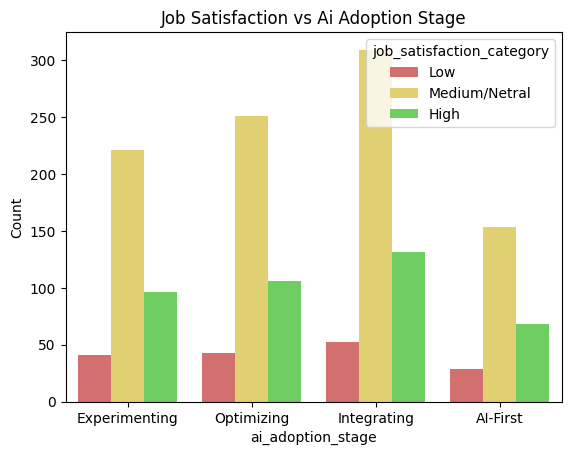

In [45]:
custom_colors = ["#e26060", "#f3dd5f", "#60e04f"]

sns.countplot(
    x='ai_adoption_stage',
    hue='job_satisfaction_category',
    data=df,
    palette=custom_colors
)

plt.title("Job Satisfaction vs Ai Adoption Stage")
plt.ylabel("Count")
plt.show()

In [46]:
df.groupby('ai_adoption_stage').agg(mean=('hours_with_ai_assistance_daily', 'mean'))

,mean
ai_adoption_stage,
AI-First,4.277600
Experimenting,4.181844
Integrating,4.221545
Optimizing,4.267750


/tmp/ipykernel_10296/1706807329.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='job_satisfaction_category', y='weekly_ai_upskilling_hrs', data=df, palette=custom_colors, errorbar=None)


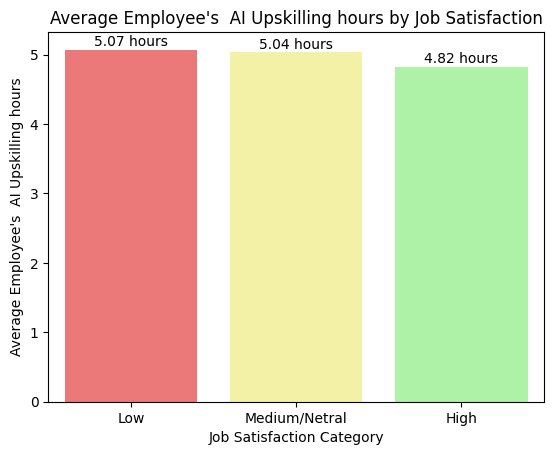

In [47]:
custom_colors = ["#ff6666", "#fffd99", "#a2ff99"]
ax = sns.barplot(x='job_satisfaction_category', y='weekly_ai_upskilling_hrs', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f} hours",
        ha='center'
    )

plt.ylabel("Average Employee's  AI Upskilling hours")
plt.xlabel("Job Satisfaction Category")
plt.title("Average Employee's  AI Upskilling hours by Job Satisfaction")
plt.show()


/tmp/ipykernel_10296/4170411931.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='job_satisfaction_category', y='productivity_score', data=df, palette=custom_colors, errorbar=None)


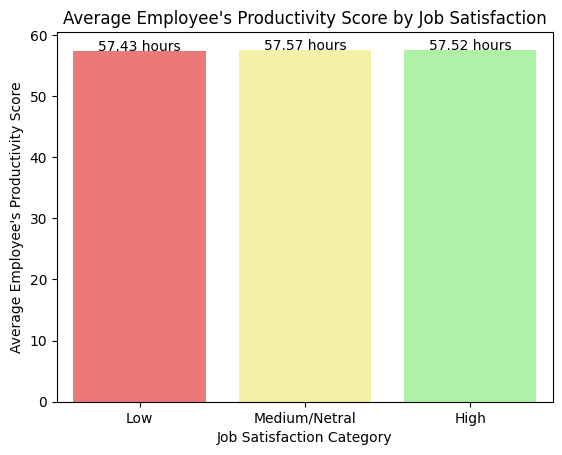

In [48]:
custom_colors = ["#ff6666", "#fffd99", "#a2ff99"]
ax = sns.barplot(x='job_satisfaction_category', y='productivity_score', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f} hours",
        ha='center'
    )

plt.ylabel("Average Employee's Productivity Score")
plt.xlabel("Job Satisfaction Category")
plt.title("Average Employee's Productivity Score by Job Satisfaction")
plt.show()


In [49]:
from scipy.stats import chi2_contingency


categorical_col = df.select_dtypes('object')
categorical_col.columns

/tmp/ipykernel_10296/255608724.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col = df.select_dtypes('object')


Index(['employee_id', 'job_role', 'education_level', 'country', 'industry',
       'company_size', 'remote_work_type', 'primary_ai_tool',
       'ai_adoption_stage', 'fear_of_ai_replacement', 'attrition_risk'],
      dtype='str')

In [50]:
categorical_col = categorical_col.drop(columns='employee_id')

In [51]:
for col in categorical_col:
    contingency_table = pd.crosstab(df[col], df['job_satisfaction_category'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print('=========================')
    print(contingency_table)
    print()
    print(f"Chi-Square: {chi2}")
    print(f"P-Value: {p}")
    print('=========================')

job_satisfaction_category  Low  Medium/Netral  High
job_role                                           
AI Ethics Officer           15             79    38
AI Researcher               16             80    39
Backend Engineer            11             80    36
Cloud Architect             13             80    37
Data Analyst                16             72    34
Data Scientist              19             80    36
DevOps Engineer             13             80    23
Frontend Engineer           10             72    34
ML Engineer                 13             67    29
Product Manager             14             79    30
Prompt Engineer             10             64    31
Software Engineer           15            101    34

Chi-Square: 10.489415606403414
P-Value: 0.981298170887069
job_satisfaction_category  Low  Medium/Netral  High
education_level                                    
Bachelor                    27            193    94
Bootcamp                    33            175    76
Maste

In [52]:
numerical_col = df.select_dtypes('number')
numerical_col.columns

Index(['years_experience', 'team_size', 'salary_usd_k',
       'ai_tools_used_per_day', 'hours_with_ai_assistance_daily',
       'ai_replaces_my_tasks_pct', 'weekly_ai_upskilling_hrs',
       'productivity_score', 'burnout_score', 'job_satisfaction_1_5'],
      dtype='str')

<Axes: >

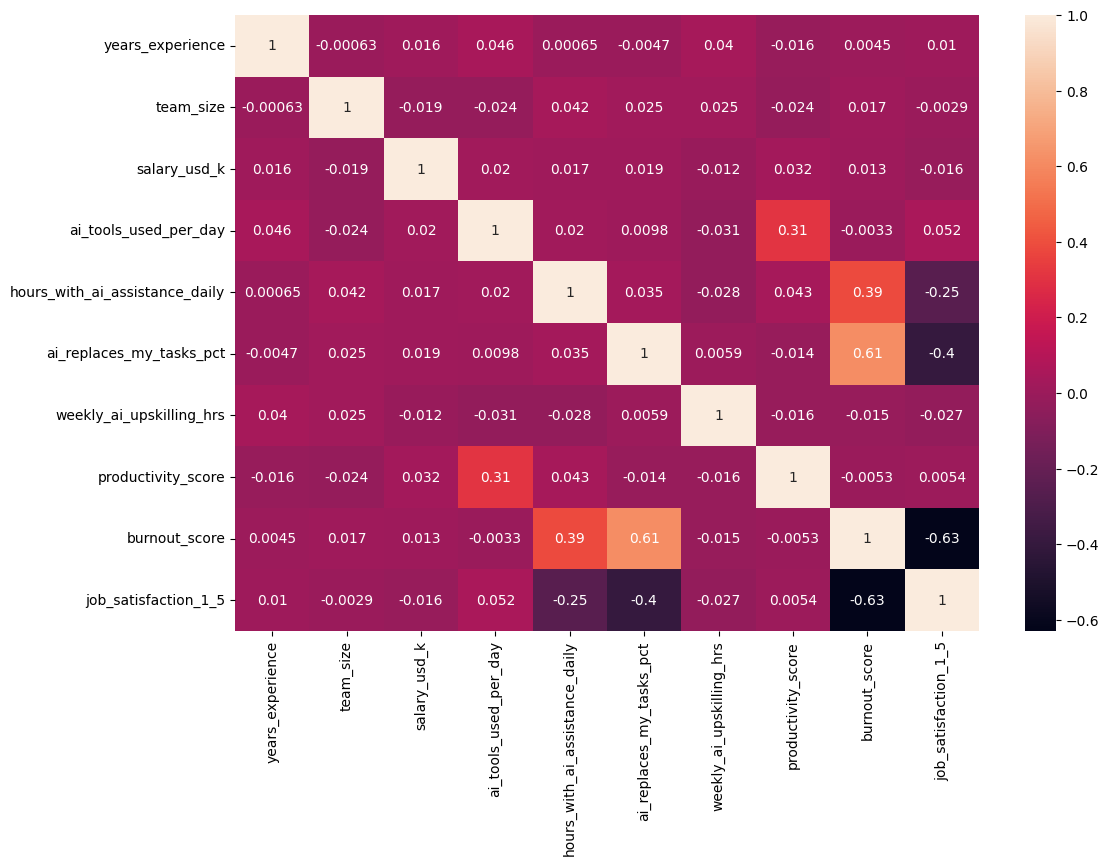

In [53]:
plt.figure(figsize=(12,8))
correlation = numerical_col.corr()
sns.heatmap(correlation, annot=True, cmap="rocket")


## Visualisasi variable yg berhubungan dengan job satisfaction

/tmp/ipykernel_10296/2408352659.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='job_satisfaction_category', y='hours_with_ai_assistance_daily', data=df, palette=custom_colors, errorbar=None)


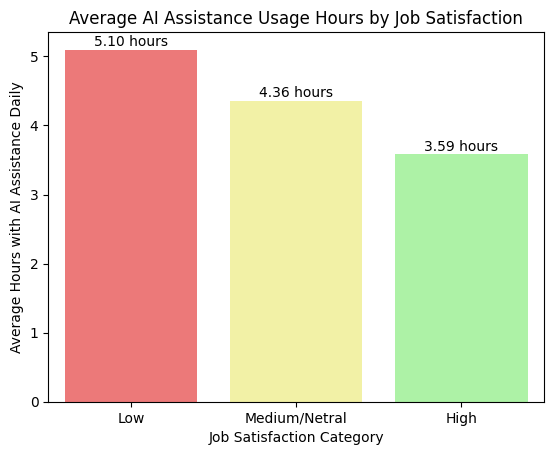

In [54]:
custom_colors = ["#ff6666", "#fffd99", "#a2ff99"]
ax = sns.barplot(x='job_satisfaction_category', y='hours_with_ai_assistance_daily', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f} hours",
        ha='center'
    )

plt.ylabel("Average Hours with AI Assistance Daily")
plt.xlabel("Job Satisfaction Category")
plt.title("Average AI Assistance Usage Hours by Job Satisfaction")
plt.show()


/tmp/ipykernel_10296/3727660582.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


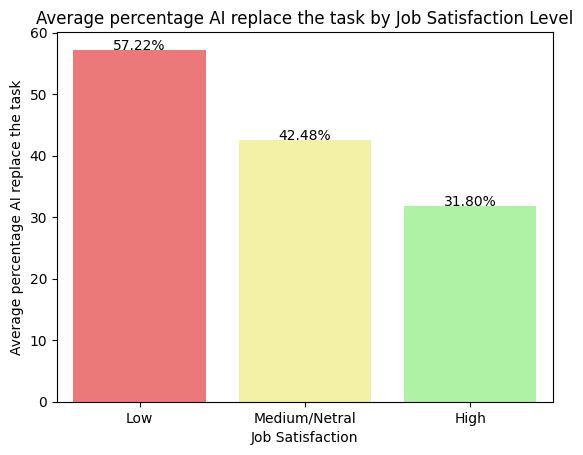

In [55]:
custom_colors = ["#ff6666", "#fffd99", "#a5ff99"]
ax = sns.barplot(
    x='job_satisfaction_category',
    y='ai_replaces_my_tasks_pct',
    data=df,
    palette=custom_colors,
    errorbar=None

)

# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}%",
        ha='center'
    )

plt.ylabel("Average percentage AI replace the task")
plt.xlabel("Job Satisfaction")
plt.title("Average percentage AI replace the task by Job Satisfaction Level")
plt.show()

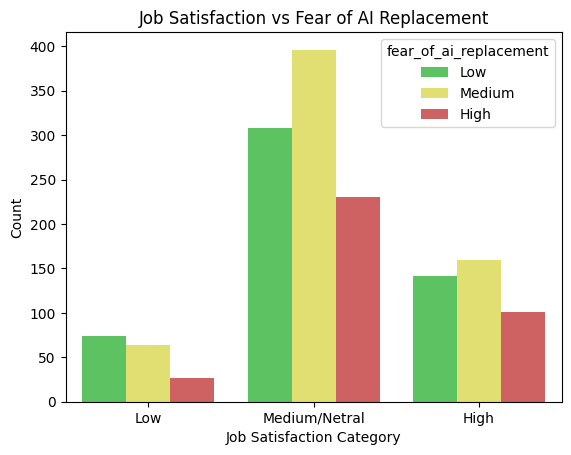

In [56]:
custom_colors = ["#4cd352", "#f3f15f", "#e04f4f"]

sns.countplot(
    x='job_satisfaction_category',
    hue='fear_of_ai_replacement',
    data=df,
    palette=custom_colors
)

plt.title("Job Satisfaction vs Fear of AI Replacement")
plt.xlabel("Job Satisfaction Category")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_10296/2857771013.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='job_satisfaction_category', y='burnout_score', data=df, palette=custom_colors, errorbar=None)


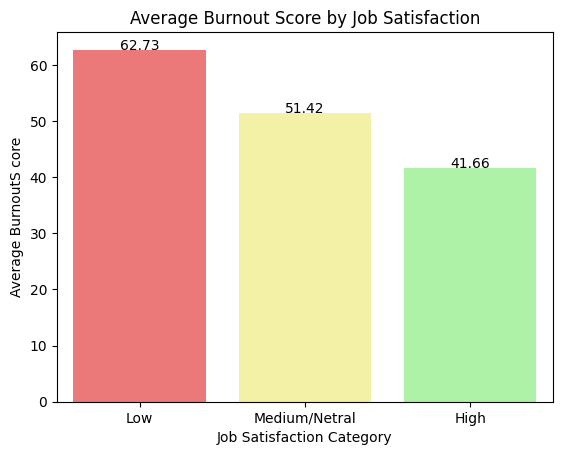

In [57]:
custom_colors = ["#ff6666", "#fffd99", "#a2ff99"]
ax = sns.barplot(x='job_satisfaction_category', y='burnout_score', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("Average BurnoutS core")
plt.xlabel("Job Satisfaction Category")
plt.title("Average Burnout Score by Job Satisfaction")
plt.show()


## Check the BoxPlot for Each Numerical Col

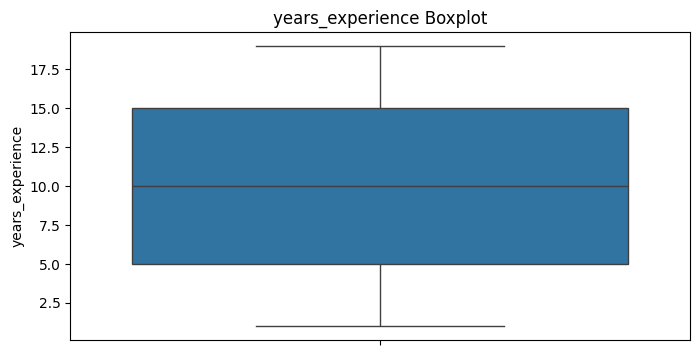

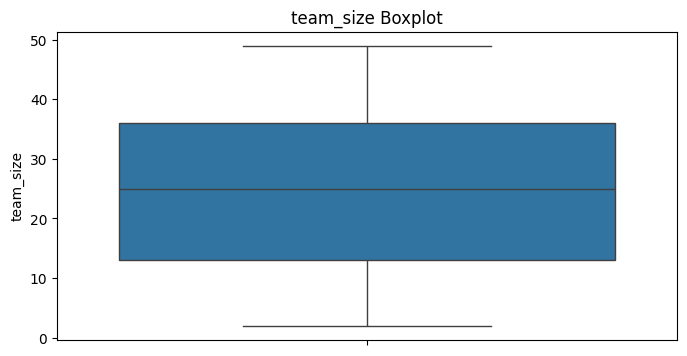

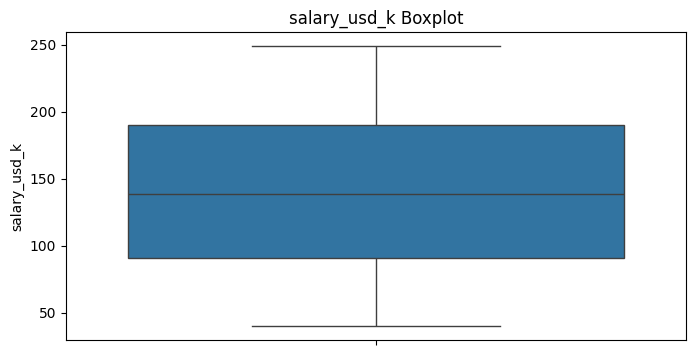

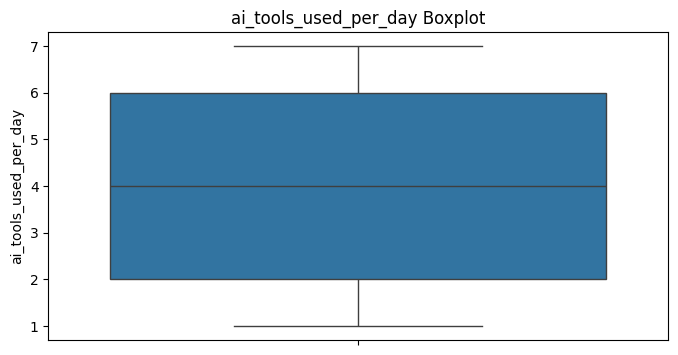

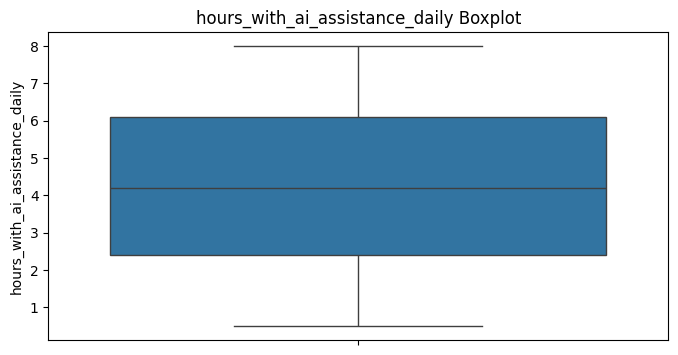

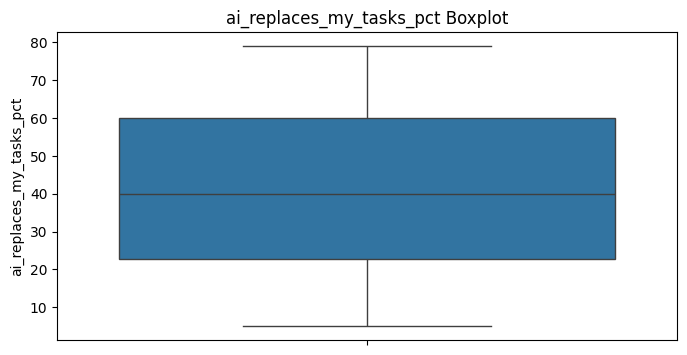

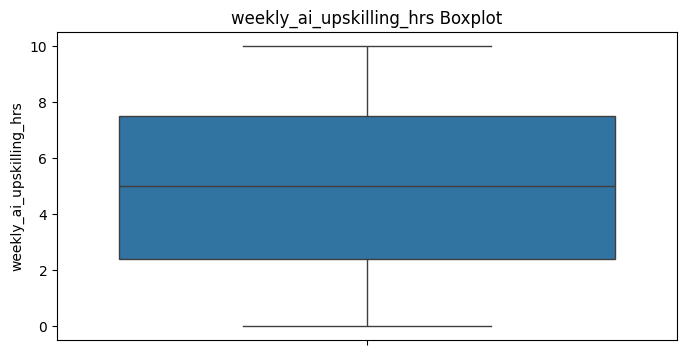

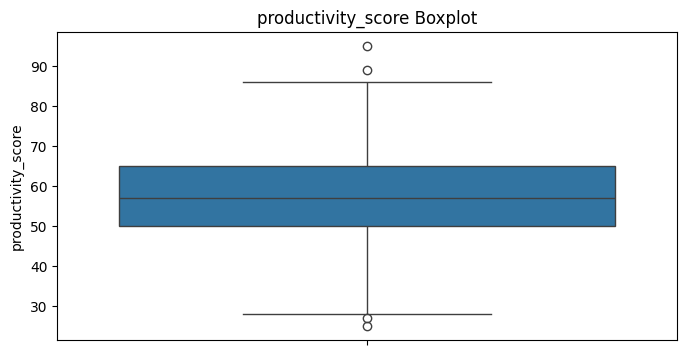

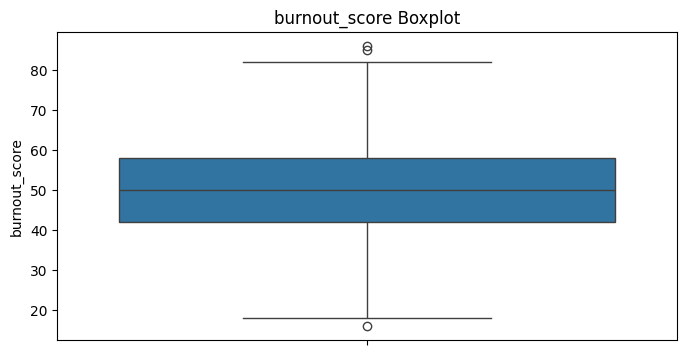

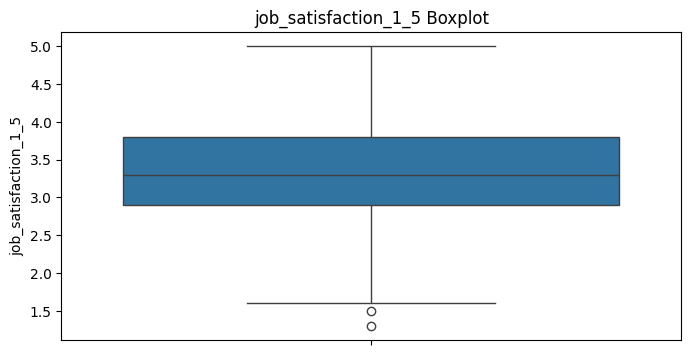

In [58]:
for col in numerical_col:
    plt.figure(figsize=(8,4))
    plt.title(f'{col} Boxplot')
    sns.boxplot(df[col])
    plt.show()


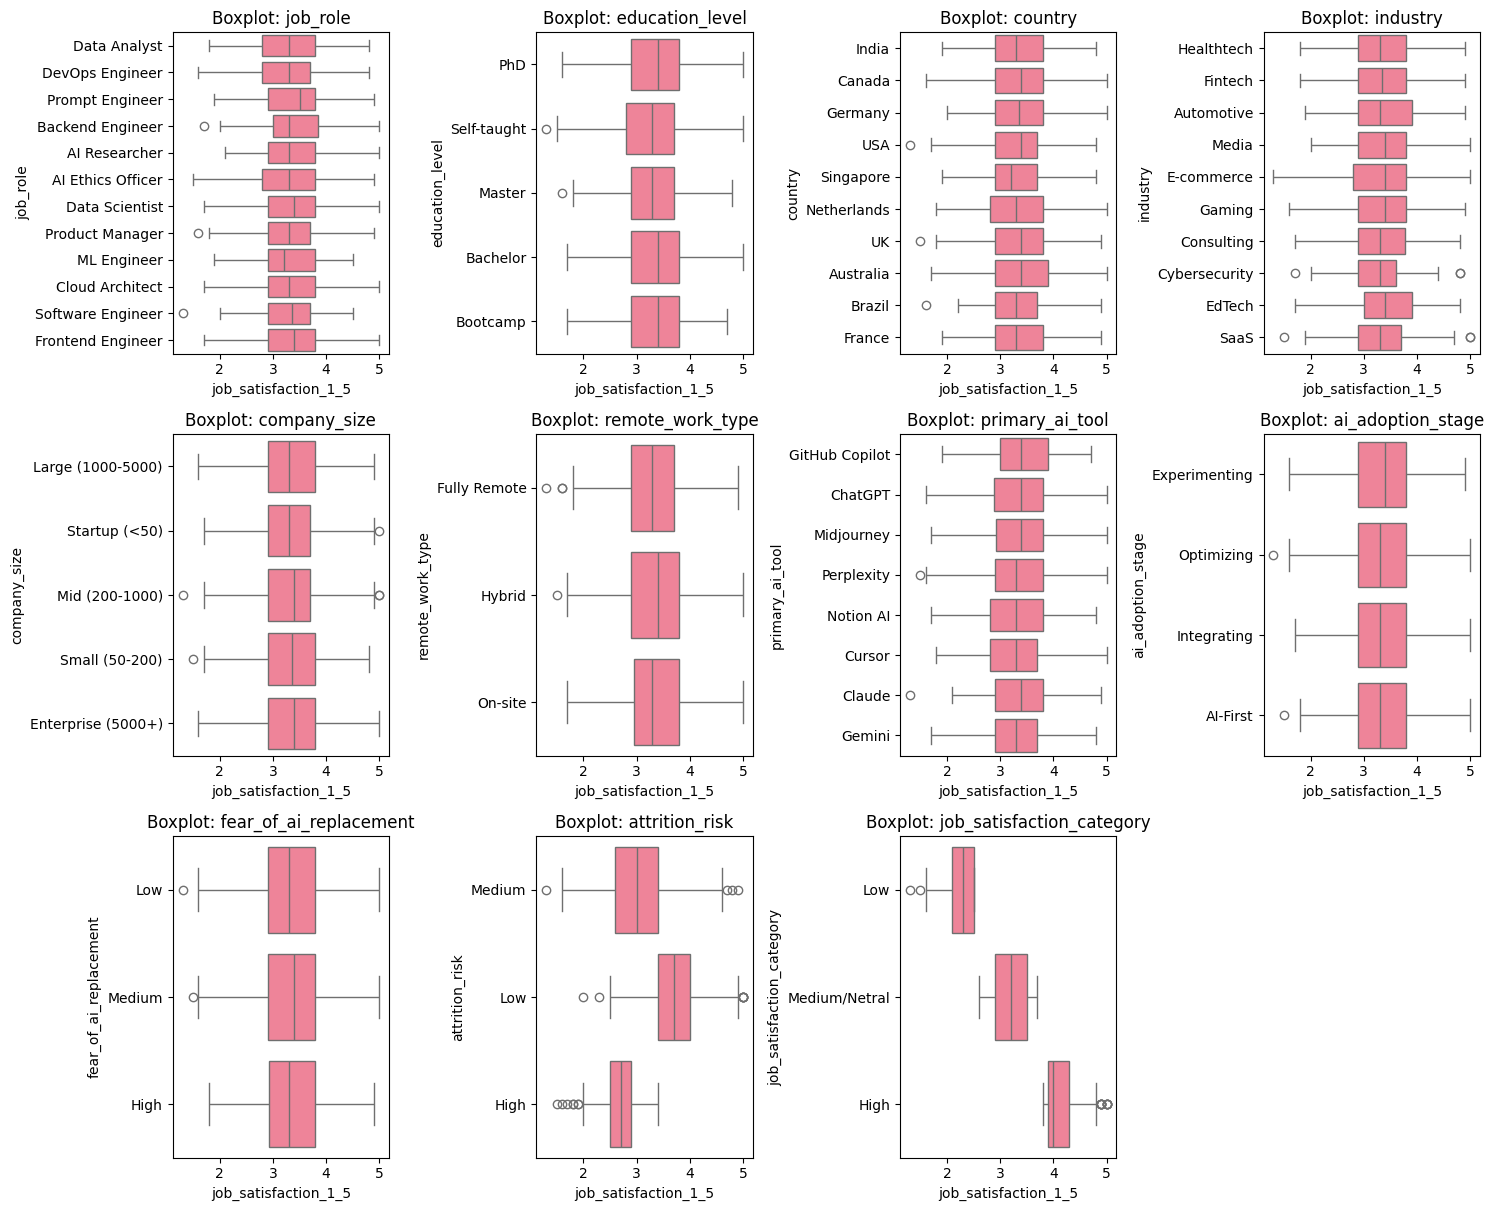

In [62]:
# Outlier

n_cols = 4
n_rows = (len(cat_cols) + n_cols - 1)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.boxplot(data=df, y=col, x="job_satisfaction_1_5", ax=axes[i], color="#FF738E")
    axes[i].set_title(f'Boxplot: {col}')
for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

# Check the distribution of the data

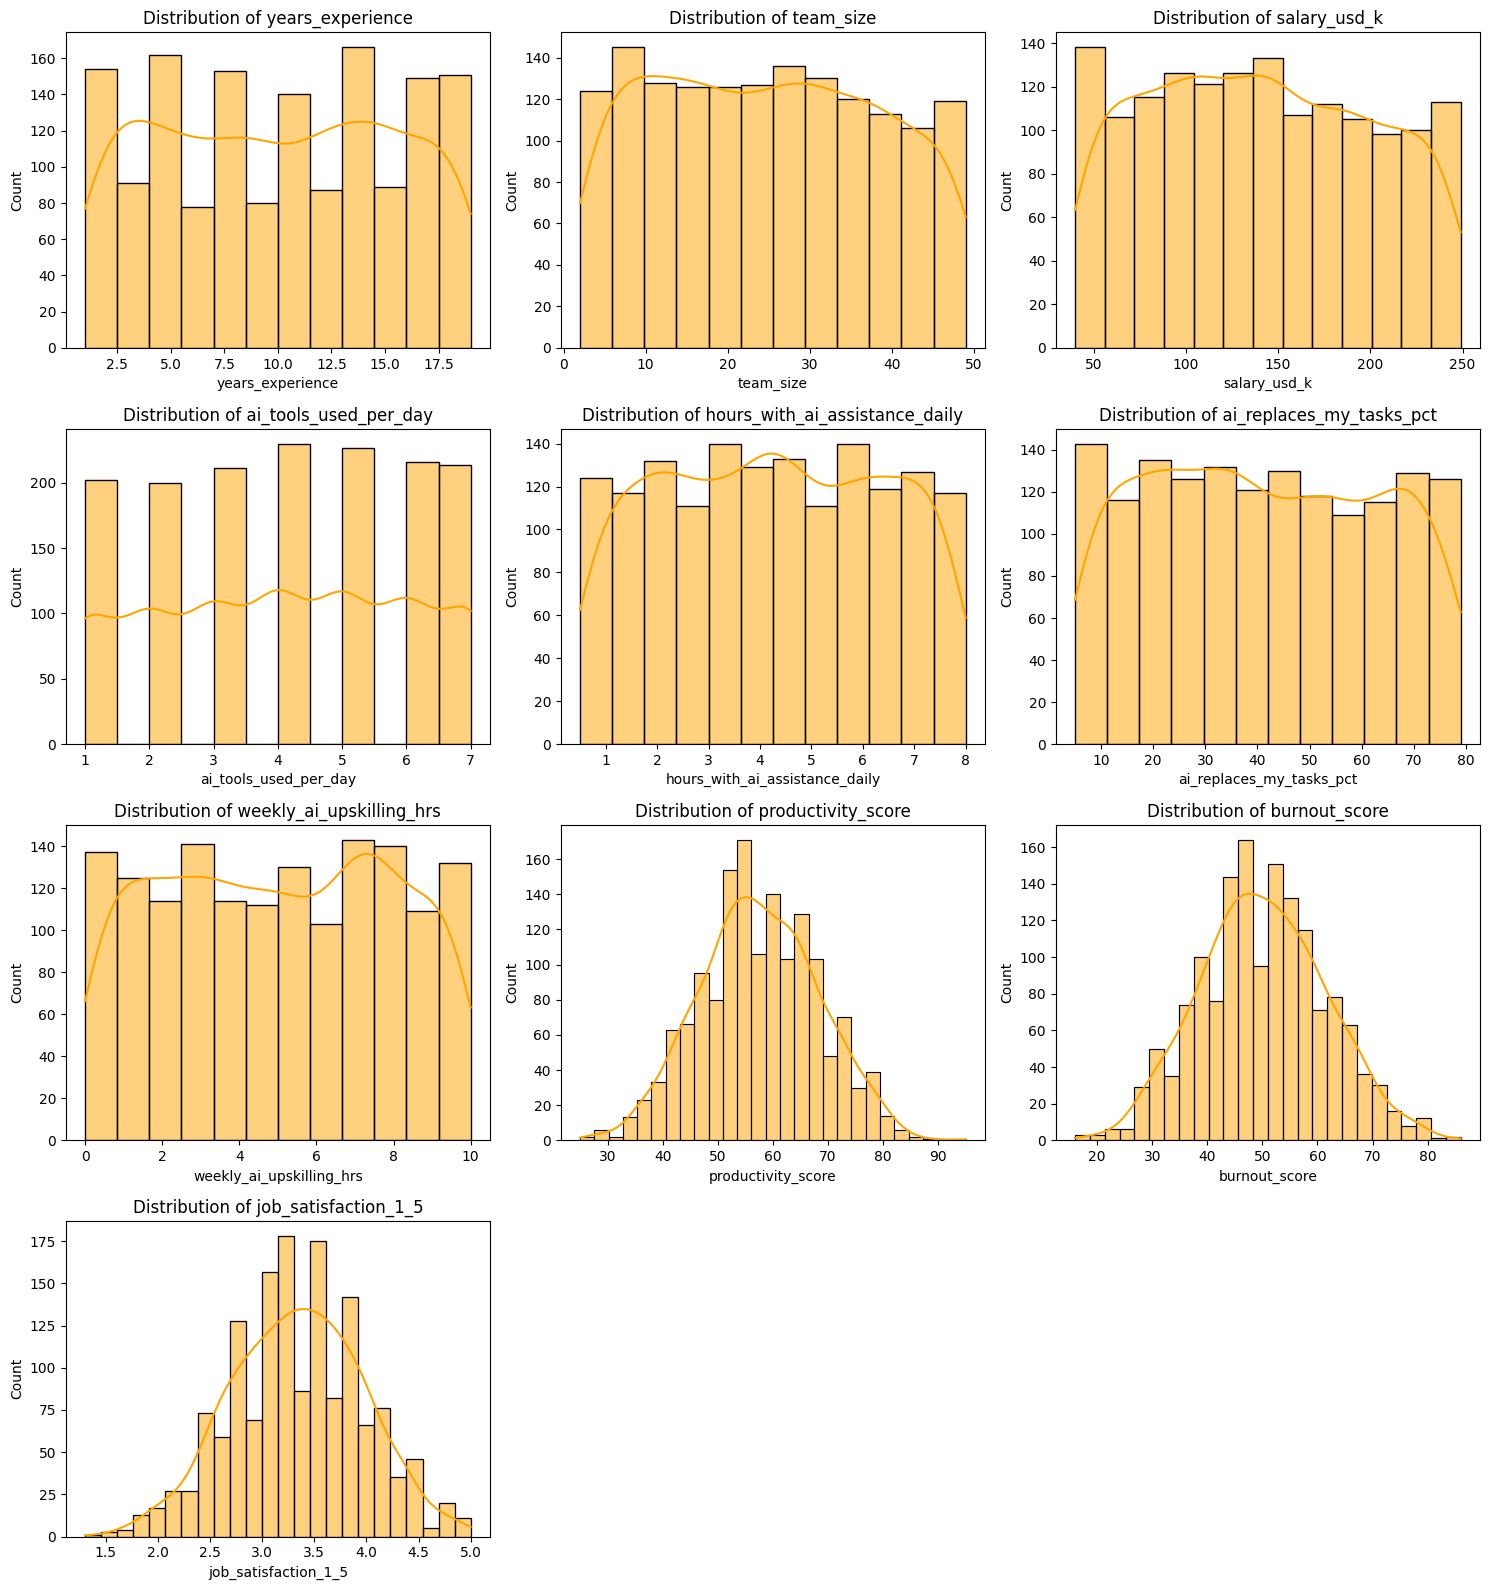

In [63]:
# pilih kolom numerik
num_cols = df.select_dtypes(include=['int64','float64']).columns

# ukuran subplot
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 4*n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True, color="orange")
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [60]:
cat_cols = df.select_dtypes(include=['object','category'])
cat_cols = cat_cols.drop('employee_id', axis=1).columns


/tmp/ipykernel_10296/2147957020.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object','category'])


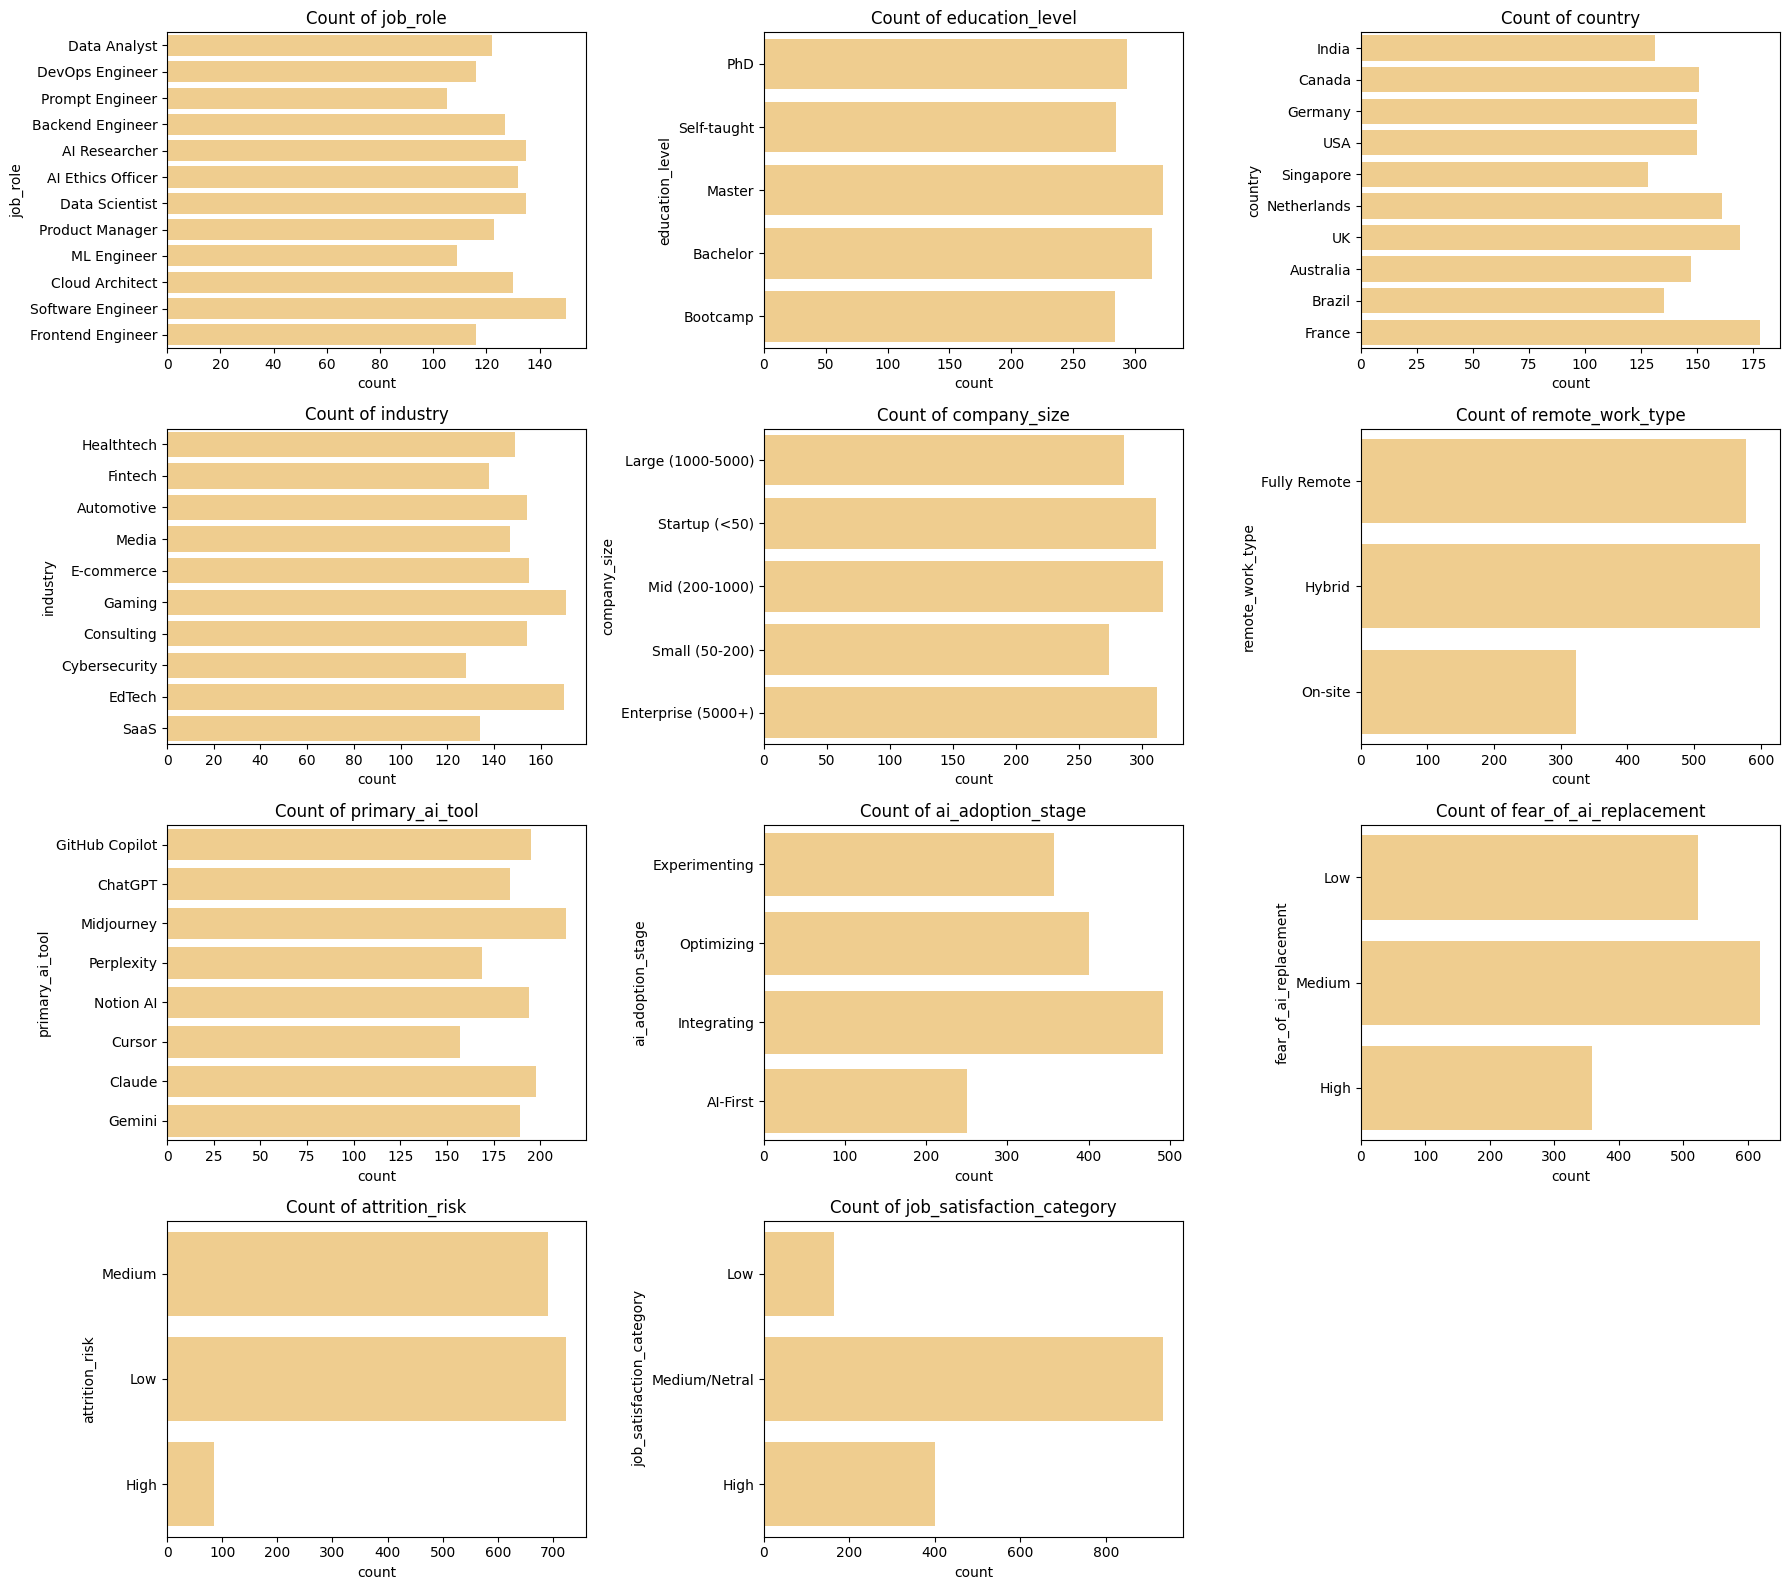

In [66]:

n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 4*n_rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(data=df, y=col, color="#FFD17F")
    plt.title(f'Count of {col}')

plt.tight_layout()
plt.show()